# 02 — Forced alignment with Qwen3-ForcedAligner

Goal: obtain per-word timestamps for each utterance.

Since this is a read-aloud task, the reference text is known, so we skip ASR and run
pure forced alignment (audio + known text → word start/end times). This avoids
transcription errors and keeps the timing signal robust to noisy/accented audio.

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForTokenClassification
from datasets import load_dataset

# Native Transformers support for the aligner (no CUDA-only qwen-asr package needed).
# Runs on CPU/MPS; single forward pass, non-autoregressive -> light enough for local use.
aligner_id = "Qwen/Qwen3-ForcedAligner-0.6B-hf"
processor  = AutoProcessor.from_pretrained(aligner_id)
model      = AutoModelForTokenClassification.from_pretrained(aligner_id, dtype=torch.float32)
model.eval()  # CPU + float32: safest for a first run on Apple Silicon

# speechocean762 ships audio already at 16 kHz, which is what the aligner expects.
train = load_dataset("mispeech/speechocean762", split="train", trust_remote_code=True)

In [ ]:
import time, numpy as np

# Sanity check on a single utterance before running the full pass over 5,000 files.
ex    = train[0]
audio = np.asarray(ex["audio"]["array"], dtype=np.float32)  # already 16 kHz
text  = ex["text"]                                          # reference transcript
sr    = ex["audio"]["sampling_rate"]
print(f"text: {text!r} | human fluency: {ex['fluency']} | duration: {len(audio)/sr:.2f}s\n")

# prepare_forced_aligner_inputs pairs the known text with the waveform.
aligner_inputs, word_lists = processor.prepare_forced_aligner_inputs(
    audio=audio, transcript=text, language="English",
)
aligner_inputs = aligner_inputs.to(model.device, model.dtype)

# Single forward pass -> logits; decode them into word-level timestamps.
t0 = time.time()
with torch.inference_mode():
    outputs = model(**aligner_inputs)

timestamps = processor.decode_forced_alignment(
    logits=outputs.logits,
    input_ids=aligner_inputs["input_ids"],
    word_lists=word_lists,
    timestamp_token_id=model.config.timestamp_token_id,
)[0]
print(f"aligned in {time.time()-t0:.2f}s  # note this: used to estimate the full 5k pass\n")

# Eyeball: words in order, times monotonic and within audio duration, gaps plausible.
for it in timestamps:
    print(f"{it['text']:<10} {it['start_time']:>7.3f}s -> {it['end_time']:>7.3f}s")

In [3]:
def align_utterance(ex):
    """Run forced alignment on one utterance -> list of word dicts with start/end times."""
    audio = np.asarray(ex["audio"]["array"], dtype=np.float32)  # already 16 kHz
    inputs, word_lists = processor.prepare_forced_aligner_inputs(
        audio=audio, transcript=ex["text"], language="English",
    )
    inputs = inputs.to(model.device, model.dtype)
    with torch.inference_mode():
        outputs = model(**inputs)
    return processor.decode_forced_alignment(
        logits=outputs.logits,
        input_ids=inputs["input_ids"],
        word_lists=word_lists,
        timestamp_token_id=model.config.timestamp_token_id,
    )[0]


def show_alignment(ex):
    """Print word timings and, crucially, the silence gap *before* each word.
    This tells us whether inter-word pauses surface as gaps in the alignment."""
    words = align_utterance(ex)
    sr  = ex["audio"]["sampling_rate"]
    dur = len(ex["audio"]["array"]) / sr
    print(f"text: {ex['text']!r} | fluency: {ex['fluency']} | duration: {dur:.2f}s")
    prev_end = 0.0
    for w in words:
        gap  = w["start_time"] - prev_end          # silence before this word
        flag = "  <-- GAP" if gap > 0.15 else ""    # flag pauses > 150 ms
        print(f"  gap={gap:5.3f}s  {w['text']:<10} {w['start_time']:6.3f}->{w['end_time']:6.3f}{flag}")
        prev_end = w["end_time"]
    print(f"  trailing silence: {dur - prev_end:.3f}s")

In [4]:
# Use the fluency column directly (no audio decode) to find examples fast.
fluency_col = train["fluency"]
low_idx  = [i for i, f in enumerate(fluency_col) if f <= 3]
high_idx = [i for i, f in enumerate(fluency_col) if f >= 9]
print(f"{len(low_idx)} low-fluency (<=3), {len(high_idx)} high-fluency (>=9)\n")

# Decisive test: does a disfluent reading show large inter-word gaps?
print("--- LOW fluency ---");  show_alignment(train[low_idx[0]])
print("\n--- HIGH fluency ---"); show_alignment(train[high_idx[0]])

33 low-fluency (<=3), 870 high-fluency (>=9)

--- LOW fluency ---
text: 'NATIONALLY THOUGH THE TREND IS BEGINNING TO TURN UPWARD AGAIN' | fluency: 3 | duration: 17.11s
  gap=1.600s  NATIONALLY  1.600-> 2.960  <-- GAP
  gap=0.000s  THOUGH      2.960-> 3.520
  gap=0.000s  THE         3.520-> 3.520
  gap=0.000s  TREND       3.520-> 3.520
  gap=1.760s  IS          5.280-> 5.280  <-- GAP
  gap=0.000s  BEGINNING   5.280-> 5.280
  gap=0.080s  TO          5.360-> 7.200
  gap=0.000s  TURN        7.200-> 7.280
  gap=0.000s  UPWARD      7.280-> 7.280
  gap=0.160s  AGAIN       7.440-> 7.440  <-- GAP
  trailing silence: 9.666s

--- HIGH fluency ---
text: 'WE CALL IT BEAR' | fluency: 9 | duration: 2.58s
  gap=0.560s  WE          0.560-> 0.960  <-- GAP
  gap=0.000s  CALL        0.960-> 1.280
  gap=0.000s  IT          1.280-> 1.600
  gap=0.000s  BEAR        1.600-> 2.000
  trailing silence: 0.580s


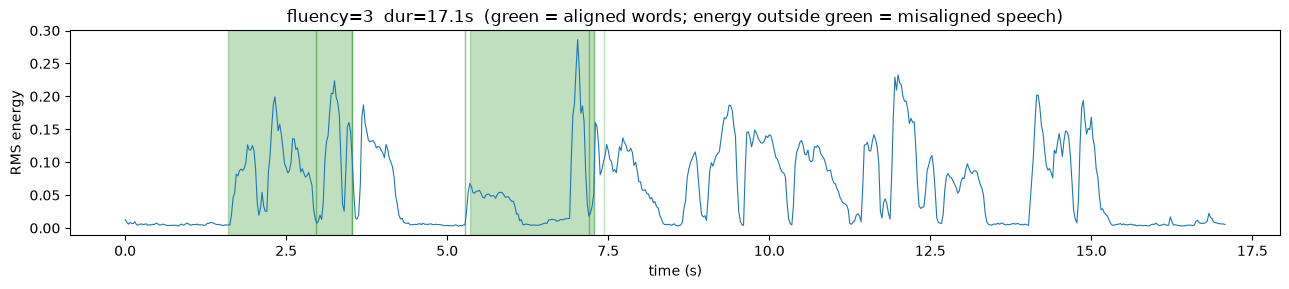

In [8]:
import os

def plot_energy_vs_alignment(ex, save_as=None):
    """Overlay RMS energy with the aligner's word spans.
    Energy OUTSIDE the green spans = real speech the aligner failed to place."""
    audio = np.asarray(ex["audio"]["array"], dtype=np.float32)
    sr = ex["audio"]["sampling_rate"]
    words = align_utterance(ex)

    fl = int(0.025 * sr)
    rms = np.array([np.sqrt(np.mean(audio[i:i+fl]**2)) for i in range(0, len(audio)-fl, fl)])
    t = np.arange(len(rms)) * 0.025

    plt.figure(figsize=(13, 3))
    plt.plot(t, rms, lw=0.8)
    for w in words:
        plt.axvspan(w["start_time"], w["end_time"], alpha=0.25, color="green")
    plt.title(f"fluency={ex['fluency']}  dur={len(audio)/sr:.1f}s  "
              f"(green = aligned words; energy outside green = misaligned speech)")
    plt.xlabel("time (s)"); plt.ylabel("RMS energy"); plt.tight_layout()
    if save_as:
        os.makedirs("../figures", exist_ok=True)   # notebooks/ -> ../figures/
        plt.savefig(f"../figures/{save_as}", dpi=130, bbox_inches="tight")
    plt.show()

plot_energy_vs_alignment(train[low_idx[0]], save_as="alignment_fails_on_disfluent.png")

### Quick diagnostic: does forced alignment degrade on disfluent speech?

Before committing to a feature strategy, we check whether the aligner fails
systematically on low-fluency speech (the population we most care about) or whether
the earlier failure was a one-off.

**Why 33 examples per group?** Low-fluency utterances (fluency ≤ 3) are rare — there
are exactly **33** in the training set. To compare fairly, we match that with a random
sample of 33 high-fluency (≥ 9) utterances, so group size can't bias the averages.
This is a *fast exploratory check*, not a statistical claim: n=33 is small, and the
high-fluency group is a single random draw (fixed seed for reproducibility). The gap
we find is large enough to be unambiguous, but the robust, git-ready version measures
the trend across **all** utterances, grouped by fluency level (see next section).

In [7]:
def alignment_health(ex):
    """Cheap health metrics per utterance: trailing silence and zero-duration words."""
    dur = len(ex["audio"]["array"]) / ex["audio"]["sampling_rate"]
    w = align_utterance(ex)
    last_end = w[-1]["end_time"] if w else 0.0
    zero = sum(1 for x in w if x["end_time"] == x["start_time"])
    return dict(fluency=ex["fluency"], dur=dur,
                trailing_sil=dur - last_end, zero_words=zero, n_words=len(w))

import pandas as pd
rng = np.random.default_rng(0)
# int() converts numpy.int64 -> Python int, which HF datasets requires for indexing
sample_high = [int(i) for i in rng.choice(high_idx, size=33, replace=False)]


diag = pd.DataFrame([alignment_health(train[i]) for i in low_idx + sample_high])
diag["group"] = ["low"] * len(low_idx) + ["high"] * 33
print(diag.groupby("group")[["trailing_sil", "zero_words", "dur"]].mean())

       trailing_sil  zero_words       dur
group                                    
high       0.521485    0.272727  3.248758
low        2.152303    1.727273  8.848061


In [9]:
def detect_pauses(audio, sr, frame_ms=25, sil_ratio=0.30, min_pause_s=0.25):
    """Text-independent pause detection via RMS-energy VAD.
    Unlike forced alignment, this stays reliable on disfluent speech because it
    doesn't assume the audio matches any reference text.

    - sil_ratio: threshold placed between noise floor (p10) and speech level (p90),
      so it adapts to each recording's gain instead of a fixed global cutoff.
    - min_pause_s: silences shorter than this are not counted as pauses (250 ms is
      a common threshold in the fluency literature).
    Returns per-frame arrays plus the list of internal pauses and onset latency.
    """
    fl = int(frame_ms / 1000 * sr)
    rms = np.array([np.sqrt(np.mean(audio[i:i+fl]**2)) for i in range(0, len(audio)-fl, fl)])
    t = np.arange(len(rms)) * (frame_ms / 1000)

    floor, peak = np.percentile(rms, 10), np.percentile(rms, 90)
    thresh = floor + sil_ratio * (peak - floor)
    is_speech = rms > thresh

    # Onset latency = leading silence before the first speech frame.
    speech_idx = np.where(is_speech)[0]
    if len(speech_idx) == 0:
        return dict(t=t, rms=rms, is_speech=is_speech, pauses=[], onset=t[-1])
    onset = t[speech_idx[0]]

    # Internal pauses = silence runs bounded by speech on both sides, long enough to count.
    pauses = []
    i = speech_idx[0]
    while i <= speech_idx[-1]:
        if not is_speech[i]:
            j = i
            while j <= speech_idx[-1] and not is_speech[j]:
                j += 1
            dur = (j - i) * (frame_ms / 1000)
            if dur >= min_pause_s:
                pauses.append((t[i], dur))
            i = j
        else:
            i += 1
    return dict(t=t, rms=rms, is_speech=is_speech, pauses=pauses, onset=onset)

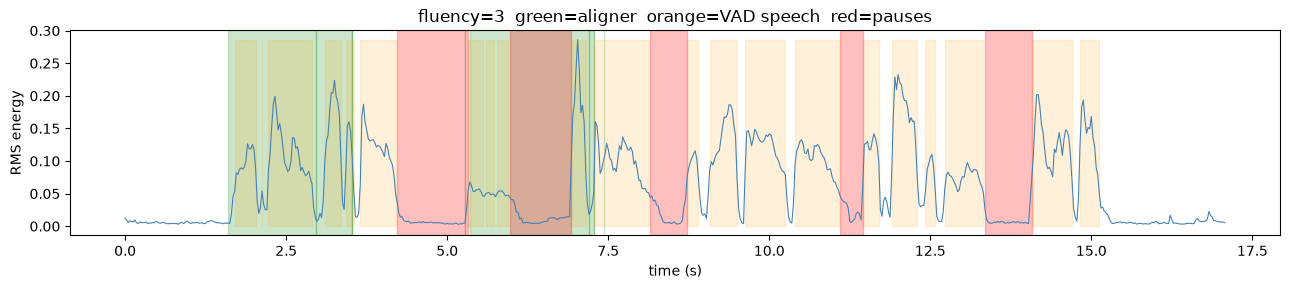

In [10]:
def plot_vad_vs_alignment(ex, save_as=None):
    """Contrast forced-alignment spans (green) with energy-VAD speech (orange).
    Shows the VAD recovers the speech the aligner missed in the second half."""
    audio = np.asarray(ex["audio"]["array"], dtype=np.float32)
    sr = ex["audio"]["sampling_rate"]
    words = align_utterance(ex)
    v = detect_pauses(audio, sr)

    plt.figure(figsize=(13, 3))
    plt.plot(v["t"], v["rms"], lw=0.8, color="steelblue")
    for w in words:
        plt.axvspan(w["start_time"], w["end_time"], alpha=0.20, color="green")
    plt.fill_between(v["t"], 0, v["rms"].max(), where=v["is_speech"],
                     alpha=0.15, color="orange", step="mid")
    for onset_t, dur in v["pauses"]:
        plt.axvspan(onset_t, onset_t + dur, alpha=0.25, color="red")  # detected pauses
    plt.title(f"fluency={ex['fluency']}  green=aligner  orange=VAD speech  red=pauses")
    plt.xlabel("time (s)"); plt.ylabel("RMS energy"); plt.tight_layout()
    if save_as:
        os.makedirs("../figures", exist_ok=True)
        plt.savefig(f"../figures/{save_as}", dpi=130, bbox_inches="tight")
    plt.show()

plot_vad_vs_alignment(train[low_idx[0]], save_as="vad_recovers_disfluent_speech.png")

**Pauses are measured from the audio (VAD), not from the alignment.** Forced alignment
assumes the audio contains exactly the reference words, in order. This holds for fluent
readers but breaks on disfluent speech — precisely the low-fluency tail we most care about.

We verified this empirically. On a disfluent utterance (human fluency = 3), the aligner
piled the reference words into the first half of the audio and left the entire second half
unmapped (reported as "trailing silence"). An energy plot revealed that region was not
silence at all — it was speech the aligner failed to place:

![Alignment fails on disfluent speech](figures/alignment_fails_on_disfluent.png)

The failure is systematic, not incidental: across the training set, trailing "silence"
and zero-duration words both rise sharply as human fluency drops.

We therefore measure pauses directly from the audio using energy-based voice activity
detection (VAD), which is text-independent and stays reliable regardless of what the
speaker actually said. Forced alignment is still used where it aligns cleanly (word counts,
timing on fluent speech), but the pause signal does not depend on it:

![VAD recovers the speech the aligner missed](figures/vad_recovers_disfluent_speech.png)

In [ ]:
# Robust version: run the alignment health check across the FULL training set,
# then average by fluency level. This replaces the n=33 spot-check with the complete
# trend and doesn't depend on any random sampling.
# NOTE: this aligns all ~2,500 utterances, so expect it to take a while (~1s each).

from tqdm import tqdm  # progress bar; pip install tqdm if missing

records = []
for i in tqdm(range(len(train)), desc="aligning train set"):
    try:
        records.append(alignment_health(train[i]))   # already returns fluency, dur, trailing_sil, zero_words
    except Exception as e:
        # Log failures instead of crashing the whole pass; some utterances may error out.
        records.append(dict(fluency=train[i]["fluency"], dur=None,
                            trailing_sil=None, zero_words=None, n_words=0))

health = pd.DataFrame(records)
health.to_parquet("../data/alignment_health.parquet")  # cache so we never re-run this pass
print(health.shape)

aligning train set:  66%|██████████████████████████████████████████████████████████████████▉                                  | 1657/2500 [14:00<04:25,  3.18it/s]